<a href="https://colab.research.google.com/github/wavymejti/KursAI1/blob/main/regresja_liniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

wzor y = 2.058015841584155x + -11.80039603960387


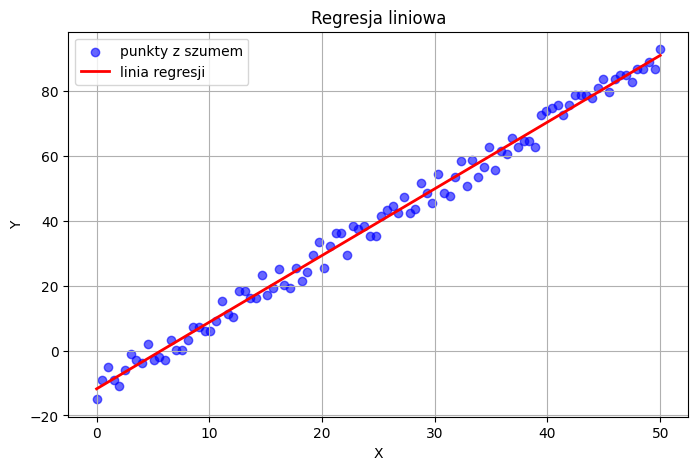

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#generowanie 100 punktow x zakresie x od 0 do 50
X = np.linspace(0,50,100)

noise = np.random.randint(-5, 5, 100) #szym losowy
Y = 2 * X - 10 + noise

a,b = regression(X,Y)
Y_pred = a*X + b

#rysowanie wykresu
plt.figure(figsize=(8,5))
plt.scatter(X,Y, color='blue', label="punkty z szumem", alpha = 0.6)
plt.plot(X, Y_pred, color='red', label="linia regresji", linewidth=2)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regresja liniowa")
plt.legend()
plt.grid()
plt.show()

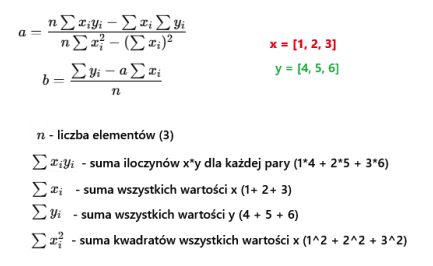

In [8]:
def regression(x,y):
  sum_of_xy = 0
  sum_x = 0
  sum_y = 0
  sum_x_squared = 0
  n = len(x)

  for x_value, y_value in zip(x,y):
    sum_of_xy += x_value * y_value
    sum_x += x_value
    sum_y += y_value
    sum_x_squared += x_value ** 2

  a = (n*sum_of_xy - sum_x*sum_y) / (n*sum_x_squared - sum_x**2)
  b = (sum_y - a*sum_x) / n

  print(f'wzor y = {a}x + {b}')
  return a,b

[0 1 2 4 5 7 9]
korelacja = 0.9998
Poziom 4: prawdziwe 92, przwidziane 91.59, różnica -0.41
Poziom 7: prawdziwe 130, przwidziane 131.81, różnica 1.81
Poziom 9: prawdziwe 160, przwidziane 158.63, różnica -1.37


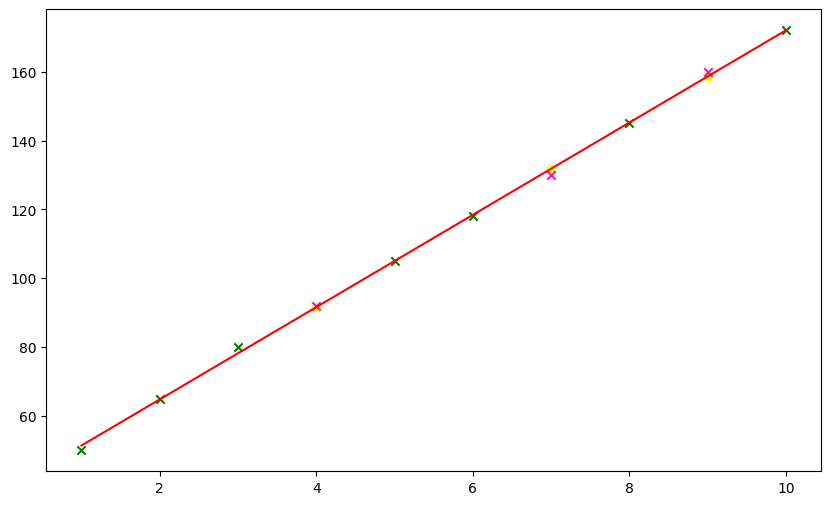

In [38]:
#DANE
x = np.arange(1,11, dtype = float) # poziom postaci
y_list = np.array([50, 65, 80, 92, 105, 118, 130, 145, 160, 172]) # średnie obrażenia

# indeksy brakujacych
missing = np.array([3,6,8])
know = np.setdiff1d(np.arange(len(x)), missing)
print(know)

#regresja na znanych punktach (bez masek i NaN)
a,b = np.polyfit(x[know], y_list[know], 1) # Corrected y indexing
y_pred = a * x + b

#korelacja na znanych wartosciach
r = np.corrcoef(x[know], y_list[know])[0,1]
print(f"korelacja = {r:.4f}")
for i in missing:
  print(f"Poziom {int(x[i])}: prawdziwe {y_list[i]}, przwidziane {y_pred[i]:.2f}, różnica {y_pred[i]- y_list[i]:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(x[know], y_list[know],label="Znane punkty", color='green', marker = 'x')
plt.scatter(x[missing], y_pred[missing],label = "przewidziane punkty", color='yellow', marker = 'o')
plt.scatter(x[missing], y_list[missing],label = "rzeczywsite", color='magenta', marker = 'x')
plt.plot(x, y_pred, color = 'red', label = 'linia regresji')
plt.show()